#  ASAP-AES : Automated Essay Scoring avec DeBERTa & CORN

**Objectif** : Prédire automatiquement le score (0-3) de réponses courtes d'étudiants

**Approche** :
-  **Entraînement par question** (un modèle par EssaySet)
-  **Deux architectures** : DeBERTa-v3-small fine-tuné + CORN (régression ordinale)
-  **Métriques** : Quadratic Weighted Kappa (QWK) + Accuracy
-  **Comparaison détaillée** avec graphiques de performance

**Dataset** : ASAP-SAS (Automated Student Assessment Prize - Short Answer Scoring)

---


## **1. Installation et imports**


In [ ]:
# Installation des packages nécessaires
!pip install -q transformers sentence-transformers torch torchvision scikit-learn pandas numpy matplotlib seaborn tqdm

print('✅ Packages installés')


In [ ]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Device: {device}')
print(f'✅ PyTorch version: {torch.__version__}')


✅ Device: cuda
✅ PyTorch version: 2.9.0+cu126


## **2. Fonctions utilitaires**


In [ ]:
def quadratic_weighted_kappa(y_true, y_pred):
    """Calcule le QWK (Cohen's Quadratic Weighted Kappa)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    min_r = min(y_true.min(), y_pred.min())
    max_r = max(y_true.max(), y_pred.max())
    n = int(max_r - min_r + 1)

    conf = np.zeros((n, n))
    for t, p in zip(y_true, y_pred):
        conf[int(t - min_r), int(p - min_r)] += 1

    w = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            w[i, j] = ((i - j) ** 2) / ((n - 1) ** 2)

    ht = conf.sum(axis=1)
    hp = conf.sum(axis=0)
    exp = np.outer(ht, hp)

    conf /= conf.sum()
    exp /= exp.sum()

    return 1 - (w * conf).sum() / (w * exp).sum()


def clear_memory():
    """Libère la mémoire GPU et RAM."""
    gc.collect()
    torch.cuda.empty_cache()


print('✅ Fonctions utilitaires définies')


✅ Fonctions utilitaires définies


## **3. Chargement et exploration des données**


In [ ]:
from google.colab import files

# Upload du fichier
#uploaded = files.upload()
df = pd.read_csv('train.tsv', sep='\t', encoding='utf-8')

print(f'✅ Dataset chargé: {df.shape[0]} réponses, {df.shape[1]} colonnes')
print(f'📋 Colonnes: {list(df.columns)}')
df.head()


✅ Dataset chargé: 17207 réponses, 5 colonnes
📋 Colonnes: ['Id', 'EssaySet', 'Score1', 'Score2', 'EssayText']


,Id,EssaySet,Score1,Score2,EssayText
0,1,1,1,1,Some additional information that we would need...
1,2,1,1,1,"After reading the expirement, I realized that ..."
2,3,1,1,1,"What you need is more trials, a control set up..."
3,4,1,0,0,The student should list what rock is better an...
4,5,1,2,2,For the students to be able to make a replicat...


In [ ]:
# ── Exploration rapide ──
print('📊 Distribution des EssaySets:')
print(df['EssaySet'].value_counts().sort_index())

print('\n📊 Distribution des scores (Score1):')
print(df['Score1'].value_counts().sort_index())

print('\n📊 Nombre de classes par EssaySet:')
for es in sorted(df['EssaySet'].unique()):
    classes = sorted(df[df['EssaySet']==es]['Score1'].unique())
    print(f'  EssaySet {es:2d}: {classes}')


📊 Distribution des EssaySets:
EssaySet
1     1672
2     1278
3     1891
4     1738
5     1795
6     1797
7     1799
8     1799
9     1798
10    1640
Name: count, dtype: int64

📊 Distribution des scores (Score1):
Score1
0    6779
1    5612
2    4075
3     741
Name: count, dtype: int64

📊 Nombre de classes par EssaySet:
  EssaySet  1: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  2: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  3: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  4: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  5: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  6: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  7: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  8: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  9: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet 10: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
# ── Nettoyage léger ──
def clean_text(text):
    text = str(text).lower().strip()
    return ' '.join(text.split())  # Normaliser espaces

df['essay_text'] = df['EssayText'].apply(clean_text)
df['score'] = df['Score1']
df['essay_set'] = df['EssaySet']

# Garder seulement les colonnes nécessaires
df = df[['essay_set', 'essay_text', 'score']].copy()

print(f'✅ Données nettoyées: {df.shape}')
df.head()


✅ Données nettoyées: (17207, 3)


,essay_set,essay_text,score
0,1,some additional information that we would need...,1
1,1,"after reading the expirement, i realized that ...",1
2,1,"what you need is more trials, a control set up...",1
3,1,the student should list what rock is better an...,0
4,1,for the students to be able to make a replicat...,2


In [ ]:
# ── Split stratifié par EssaySet (70/15/15) ──
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['essay_set'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['essay_set'])

print(f'✅ Split effectué:')
print(f'  Train: {len(df_train):5d} ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Val  : {len(df_val):5d} ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test : {len(df_test):5d} ({len(df_test)/len(df)*100:.1f}%)')

# Vérifier stratification
print('\n📊 Distribution par EssaySet:')
for name, dset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    sets = sorted(dset['essay_set'].unique())
    print(f'  {name:5s}: {sets}')


✅ Split effectué:
  Train: 12044 (70.0%)
  Val  :  2581 (15.0%)
  Test :  2582 (15.0%)

📊 Distribution par EssaySet:
  Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Val  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Test : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## **4. Feature engineering avec Sentence-BERT**


In [ ]:
# ── Charger SBERT ──
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ SBERT chargé (dimension: 384)')

# ── Encoder les ensembles ──
print('\n🔄 Encodage des textes...')
train_embeddings = sbert.encode(df_train['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)
val_embeddings = sbert.encode(df_val['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)
test_embeddings = sbert.encode(df_test['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)

print(f'\n✅ Embeddings générés:')
print(f'  Train: {train_embeddings.shape}')
print(f'  Val  : {val_embeddings.shape}')
print(f'  Test : {test_embeddings.shape}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ SBERT chargé (dimension: 384)

🔄 Encodage des textes...


Batches:   0%|          | 0/377 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]


✅ Embeddings générés:
  Train: (12044, 384)
  Val  : (2581, 384)
  Test : (2582, 384)


## **5. Modèle CORN (Conditional Ordinal Regression)**

CORN est une approche de régression ordinale qui prédit K-1 probabilités conditionnelles :
- P(y = k | y ≥ k) pour k = 0, 1, ..., K-2

**Avantages** :
- Respecte l'ordre naturel des scores (0 < 1 < 2 < 3)
- Pénalise moins les erreurs adjacentes (0→1) que les erreurs extrêmes (0→3)
- Pas de contrainte de poids partagé (contrairement à CORAL)


In [ ]:
class CORNModel(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, num_classes=4, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(num_classes - 1)])

    def forward(self, x):
        h = self.trunk(x)
        logits = torch.cat([head(h) for head in self.heads], dim=1)
        return logits

    def predict_proba(self, x):
        logits = self.forward(x)
        sigs = torch.sigmoid(logits)

        probs = []
        remaining = torch.ones(logits.shape[0], 1, device=logits.device)

        for k in range(self.num_classes - 1):
            p_k = remaining * (1.0 - sigs[:, k:k+1])
            probs.append(p_k)
            remaining = remaining * sigs[:, k:k+1]

        probs.append(remaining)
        return torch.cat(probs, dim=1)


def corn_loss(logits, labels, num_classes):
    loss = torch.tensor(0.0, device=logits.device)
    count = 0

    for k in range(num_classes - 1):
        mask = labels >= k
        if mask.sum() == 0:
            continue

        logit_k = logits[mask, k]
        target_k = (labels[mask] > k).float()
        loss += F.binary_cross_entropy_with_logits(logit_k, target_k)
        count += 1

    return loss / max(count, 1)


class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.X = torch.FloatTensor(embeddings)
        self.y = torch.LongTensor(labels)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'features': self.X[idx], 'label': self.y[idx]}


print('✅ CORN model défini')


✅ CORN model défini


In [ ]:
def train_corn(embeddings_tr, y_tr, embeddings_val, y_val, num_classes,
               epochs=40, lr=0.001, patience=8, batch_size=32):
    """Entraîne CORN sur un EssaySet."""

    train_ds = EmbeddingDataset(embeddings_tr, y_tr)
    val_ds = EmbeddingDataset(embeddings_val, y_val)

    # ── CRITIQUE : drop_last=True pour éviter les batchs de taille 1 ──
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)  # Pas de drop_last en val

    model = CORNModel(input_dim=384, hidden_dim=128, num_classes=num_classes, dropout=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        total_samples = 0  # ← Compter les échantillons réellement traités

        for batch in train_dl:
            X = batch['features'].to(device)
            y = batch['label'].to(device)

            logits = model(X)
            loss = corn_loss(logits, y, num_classes)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X.size(0)
            total_samples += X.size(0)

        train_loss /= max(total_samples, 1)  # ← Diviser par échantillons réels

        # Val
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_dl:
                X = batch['features'].to(device)
                y = batch['label'].to(device)

                logits = model(X)
                val_loss += corn_loss(logits, y, num_classes).item() * X.size(0)

                probs = model.predict_proba(X)
                preds = probs.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        star = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
            star = ' ⭐'
        else:
            counter += 1
            if counter >= patience:
                break

        if epoch % 5 == 0 or star:
            print(f'    Epoch {epoch:2d} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
                  f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


print('✅ Fonction train_corn corrigée')

✅ Fonction train_corn corrigée


## **6. Entraînement CORN par EssaySet**

On entraîne un modèle séparé pour chaque question pour respecter l'hétérogénéité des sujets.


In [ ]:
corn_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'  🚀 CORN - EssaySet {es}')
    print(f'{'='*60}')

    # Filtrer données
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    embeddings_tr = train_embeddings[train_mask]
    y_tr = df_train.loc[train_mask, 'score'].values

    embeddings_val = val_embeddings[val_mask]
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper scores → indices
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    # Entraîner
    model, history = train_corn(
        embeddings_tr, y_tr_mapped,
        embeddings_val, y_val_mapped,
        num_classes=n_classes,
        epochs=40, lr=0.001, patience=8
    )

    corn_models[es] = (model, history, n_classes, score_map)
    clear_memory()

print(f'\n✅ {len(corn_models)} modèles CORN entraînés')



  🚀 CORN - EssaySet 1
  Train: 1170 | Val:  251 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4
    Epoch  1 | Loss: 0.5755 → 0.5822 | QWK: 0.5751 | Acc: 0.4701 ⭐
    Epoch  2 | Loss: 0.4619 → 0.4878 | QWK: 0.6391 | Acc: 0.5458 ⭐
    Epoch  3 | Loss: 0.4095 → 0.4812 | QWK: 0.6537 | Acc: 0.5179 ⭐
    Epoch  5 | Loss: 0.3569 → 0.4698 | QWK: 0.6777 | Acc: 0.5857 ⭐
    Epoch  6 | Loss: 0.3275 → 0.4582 | QWK: 0.6886 | Acc: 0.5817 ⭐
    Epoch 10 | Loss: 0.2579 → 0.4820 | QWK: 0.6964 | Acc: 0.5777

  🚀 CORN - EssaySet 2
  Train:  895 | Val:  192 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4
    Epoch  1 | Loss: 0.5792 → 0.5631 | QWK: 0.3634 | Acc: 0.3646 ⭐
    Epoch  2 | Loss: 0.4748 → 0.5025 | QWK: 0.5193 | Acc: 0.4375 ⭐
    Epoch  3 | Loss: 0.4319 → 0.4740 | QWK: 0.5752 | Acc: 0.4479 ⭐
    Epoch  4 | Loss: 0.3991 → 0.4494 | QWK: 0.5799 | Acc: 0.4844 ⭐
    Epoch  5 | Loss: 0.3702 → 0.4437 | QWK: 0.6181 | Acc: 0.4948 ⭐
    Epoch 10 | Loss: 0.2611 → 0

## **7. Fine-tuning DeBERTa-v3-small**

DeBERTa-v3-small (44M paramètres) est fine-tuné sur chaque question.
- Architecture : Transformers → [CLS] → Linear(768 → num_classes)
- Loss : CrossEntropyLoss pondérée par classe
- Optimiseur : AdamW avec warmup scheduler


In [ ]:
class DeBERTaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


print('✅ DeBERTaDataset défini')


✅ DeBERTaDataset défini


In [ ]:
def train_deberta(texts_tr, y_tr, texts_val, y_val, num_classes,
                  epochs=3, lr=2e-5, batch_size=8, max_len=96):
    """Fine-tune DeBERTa sur un EssaySet."""

    tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')
    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-small',
        num_labels=num_classes,
        dtype=torch.float32
    ).to(device)

    train_ds = DeBERTaDataset(texts_tr, y_tr, tokenizer, max_len)
    val_ds = DeBERTaDataset(texts_val, y_val, tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Class weights
    counts = np.bincount(y_tr, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    weights = torch.FloatTensor(len(y_tr) / (num_classes * counts)).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps
    )

    best_val_loss = float('inf')
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_dl, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for batch in pbar:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item() * ids.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(y_tr)

        # Val
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_dl:
                ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids=ids, attention_mask=mask)
                val_loss += criterion(outputs.logits, labels).item() * ids.size(0)

                preds = outputs.logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        star = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            star = ' ⭐'

        print(f'    Epoch {epoch} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
              f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

    model.load_state_dict(best_state)
    model.to(device)
    return model, tokenizer, history


print('✅ Fonction train_deberta définie')


✅ Fonction train_deberta définie


## **8. Entraînement DeBERTa par EssaySet**


In [ ]:
def train_deberta(texts_tr, y_tr, texts_val, y_val, num_classes,
                  epochs=3, lr=2e-5, batch_size=8, max_len=96, patience=3):
    """Fine-tune DeBERTa avec Early Stopping."""

    tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')
    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-small',
        num_labels=num_classes,
        dtype=torch.float32
    ).to(device)

    # ... [Code de préparation des datasets/loaders identique] ...
    train_ds = DeBERTaDataset(texts_tr, y_tr, tokenizer, max_len)
    val_ds = DeBERTaDataset(texts_val, y_val, tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Class weights & Optimizer
    counts = np.bincount(y_tr, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    weights = torch.FloatTensor(len(y_tr) / (num_classes * counts)).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps
    )

    # --- LOGIQUE EARLY STOPPING ---
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # [Phase de Train identique à ton code]
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_dl, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for batch in pbar:
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, labels)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            train_loss += loss.item() * ids.size(0)

        train_loss /= len(y_tr)

        # [Phase de Val identique à ton code]
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_dl:
                ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
                outputs = model(input_ids=ids, attention_mask=mask)
                val_loss += criterion(outputs.logits, labels).item() * ids.size(0)
                preds = outputs.logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy()); all_labels.extend(labels.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        # --- MISE À JOUR EARLY STOPPING ---
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            star = ' ⭐'
        else:
            epochs_no_improve += 1
            star = ''

        print(f'    Epoch {epoch} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
              f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

        if epochs_no_improve >= patience:
            print(f'🛑 Early stopping déclenché à l\'époque {epoch} !')
            break

    model.load_state_dict(best_state)
    return model, tokenizer, history

In [ ]:
#Augmente le nombre des époches
deberta_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'  🚀 DeBERTa - EssaySet {es}')
    print(f'{'='*60}')

    clear_memory()

    # Filtrer
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    texts_tr = df_train.loc[train_mask, 'essay_text'].tolist()
    y_tr = df_train.loc[train_mask, 'score'].values

    texts_val = df_val.loc[val_mask, 'essay_text'].tolist()
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    # Entraîner
    model, tokenizer, history = train_deberta(
        texts_tr, y_tr_mapped,
        texts_val, y_val_mapped,
        num_classes=n_classes,
        epochs=60, patience=4, lr=2e-5, batch_size=4 # Reduced batch_size from 8 to 4
    )

    deberta_models[es] = (model, tokenizer, history, n_classes, score_map)
    clear_memory()

print(f'\n✅ {len(deberta_models)} modèles DeBERTa entraînés')


  🚀 DeBERTa - EssaySet 1
  Train: 1170 | Val:  251 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight     

Epoch 1/60:   0%|          | 0/293 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 376.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 6.12 MiB is free. Process 171791 has 14.73 GiB memory in use. Of the allocated memory 14.29 GiB is allocated by PyTorch, and 319.04 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## **9. Prédictions sur le test set**


In [ ]:
def predict_corn(model, embeddings, score_map):
    """Prédictions CORN avec remapping vers scores originaux."""
    model.eval()
    ds = EmbeddingDataset(embeddings, np.zeros(len(embeddings)))
    loader = DataLoader(ds, batch_size=64, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch['features'].to(device)
            probs = model.predict_proba(X)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    preds = np.array(all_preds)
    inv_map = {i: s for s, i in score_map.items()}
    preds_orig = np.array([inv_map[p] for p in preds])
    return preds_orig


def predict_deberta(model, tokenizer, texts, score_map):
    """Prédictions DeBERTa avec remapping vers scores originaux."""
    model.eval()
    ds = DeBERTaDataset(texts, np.zeros(len(texts)), tokenizer, max_len=96)
    loader = DataLoader(ds, batch_size=16, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    preds = np.array(all_preds)
    inv_map = {i: s for s, i in score_map.items()}
    preds_orig = np.array([inv_map[p] for p in preds])
    return preds_orig


print('✅ Fonctions de prédiction définies')


✅ Fonctions de prédiction définies


In [ ]:
print('🔄 Génération des prédictions sur test...\n')

preds_corn_test = np.zeros(len(df_test), dtype=int)
preds_deb_test = np.zeros(len(df_test), dtype=int)

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    idx = np.where(mask)[0]

    print(f'  EssaySet {es:2d}: {len(idx):4d} essays', end='')

    # CORN
    if es in corn_models:
        model_c, _, _, score_map_c = corn_models[es]
        emb_test = test_embeddings[mask]
        preds_corn_test[idx] = predict_corn(model_c, emb_test, score_map_c)
        print(' | CORN ✓', end='')

    # DeBERTa
    if es in deberta_models:
        model_d, tok_d, _, _, score_map_d = deberta_models[es]
        texts_test = df_test.loc[mask, 'essay_text'].tolist()
        preds_deb_test[idx] = predict_deberta(model_d, tok_d, texts_test, score_map_d)
        print(' | DeBERTa ✓')

y_test = df_test['score'].values

print(f'\n✅ Prédictions générées')
print(f'   preds_corn : {preds_corn_test.shape} | range=[{preds_corn_test.min()}, {preds_corn_test.max()}]')
print(f'   preds_deb  : {preds_deb_test.shape} | range=[{preds_deb_test.min()}, {preds_deb_test.max()}]')


🔄 Génération des prédictions sur test...

  EssaySet  1:  251 essays | CORN ✓ | DeBERTa ✓
  EssaySet  2:  191 essays | CORN ✓ | DeBERTa ✓
  EssaySet  3:  284 essays | CORN ✓ | DeBERTa ✓
  EssaySet  4:  260 essays | CORN ✓ | DeBERTa ✓
  EssaySet  5:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  6:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  7:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  8:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  9:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet 10:  246 essays | CORN ✓
✅ Prédictions générées
   preds_corn : (2582,) | range=[0, 3]
   preds_deb  : (2582,) | range=[0, 3]


In [ ]:
#nombre des epoches augmente
print('🔄 Génération des prédictions sur test...\n')

preds_corn_test = np.zeros(len(df_test), dtype=int)
preds_deb_test = np.zeros(len(df_test), dtype=int)

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    idx = np.where(mask)[0]

    print(f'  EssaySet {es:2d}: {len(idx):4d} essays', end='')

    # CORN
    if es in corn_models:
        model_c, _, _, score_map_c = corn_models[es]
        emb_test = test_embeddings[mask]
        preds_corn_test[idx] = predict_corn(model_c, emb_test, score_map_c)
        print(' | CORN ✓', end='')

    # DeBERTa
    if es in deberta_models:
        model_d, tok_d, _, _, score_map_d = deberta_models[es]
        texts_test = df_test.loc[mask, 'essay_text'].tolist()
        preds_deb_test[idx] = predict_deberta(model_d, tok_d, texts_test, score_map_d)
        print(' | DeBERTa ✓')

y_test = df_test['score'].values

print(f'\n✅ Prédictions générées')
print(f'   preds_corn : {preds_corn_test.shape} | range=[{preds_corn_test.min()}, {preds_corn_test.max()}]')
print(f'   preds_deb  : {preds_deb_test.shape} | range=[{preds_deb_test.min()}, {preds_deb_test.max()}]')


🔄 Génération des prédictions sur test...

  EssaySet  1:  251 essays | CORN ✓ | DeBERTa ✓
  EssaySet  2:  191 essays | CORN ✓ | DeBERTa ✓
  EssaySet  3:  284 essays | CORN ✓ | DeBERTa ✓
  EssaySet  4:  260 essays | CORN ✓ | DeBERTa ✓
  EssaySet  5:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  6:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  7:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  8:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  9:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet 10:  246 essays | CORN ✓
✅ Prédictions générées
   preds_corn : (2582,) | range=[0, 3]
   preds_deb  : (2582,) | range=[0, 3]


## **10. Évaluation et comparaison des modèles**


In [ ]:
# ══════════════════════════════════════════════════════════
# MÉTRIQUES GLOBALES
# ══════════════════════════════════════════════════════════

qwk_corn = quadratic_weighted_kappa(y_test, preds_corn_test)
acc_corn = accuracy_score(y_test, preds_corn_test)

qwk_deb = quadratic_weighted_kappa(y_test, preds_deb_test)
acc_deb = accuracy_score(y_test, preds_deb_test)

print('='*60)
print('📊 RÉSULTATS FINAUX SUR TEST SET')
print('='*60)
print(f'{'Modèle':<20} {'QWK':>10} {'Accuracy':>10}')
print('-'*60)
print(f'{'CORN':<20} {qwk_corn:>10.4f} {acc_corn:>10.4f}')
print(f'{'DeBERTa-v3-small':<20} {qwk_deb:>10.4f} {acc_deb:>10.4f}')
print('='*60)

winner = 'CORN' if qwk_corn > qwk_deb else 'DeBERTa'
diff = abs(qwk_corn - qwk_deb)
print(f'\n🏆 Meilleur modèle: {winner} (Δ QWK = {diff:.4f})')


📊 RÉSULTATS FINAUX SUR TEST SET
Modèle                      QWK   Accuracy
------------------------------------------------------------
CORN                     0.6933     0.6847
DeBERTa-v3-small         0.6245     0.5995

🏆 Meilleur modèle: CORN (Δ QWK = 0.0688)


In [ ]:
# ══════════════════════════════════════════════════════════
#nombre des epoches augmente
# MÉTRIQUES GLOBALES
# ══════════════════════════════════════════════════════════

qwk_corn = quadratic_weighted_kappa(y_test, preds_corn_test)
acc_corn = accuracy_score(y_test, preds_corn_test)

qwk_deb = quadratic_weighted_kappa(y_test, preds_deb_test)
acc_deb = accuracy_score(y_test, preds_deb_test)

print('='*60)
print('📊 RÉSULTATS FINAUX SUR TEST SET')
print('='*60)
print(f'{'Modèle':<20} {'QWK':>10} {'Accuracy':>10}')
print('-'*60)
print(f'{'CORN':<20} {qwk_corn:>10.4f} {acc_corn:>10.4f}')
print(f'{'DeBERTa-v3-small':<20} {qwk_deb:>10.4f} {acc_deb:>10.4f}')
print('='*60)

winner = 'CORN' if qwk_corn > qwk_deb else 'DeBERTa'
diff = abs(qwk_corn - qwk_deb)
print(f'\n🏆 Meilleur modèle: {winner} (Δ QWK = {diff:.4f})')


📊 RÉSULTATS FINAUX SUR TEST SET
Modèle                      QWK   Accuracy
------------------------------------------------------------
CORN                     0.6933     0.6847
DeBERTa-v3-small         0.6245     0.5995

🏆 Meilleur modèle: CORN (Δ QWK = 0.0688)


In [ ]:
# ══════════════════════════════════════════════════════════
# PERFORMANCE PAR EssaySet
# ══════════════════════════════════════════════════════════

print('\n📋 Performance par EssaySet:\n')
print(f'{'EssaySet':<12} {'N':>5} | {'CORN QWK':>10} {'CORN Acc':>10} | {'DeBERTa QWK':>12} {'DeBERTa Acc':>12} | {'Winner':>8}')
print('-'*90)

results_by_es = []

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    y_es = y_test[mask]
    preds_c = preds_corn_test[mask]
    preds_d = preds_deb_test[mask]

    qwk_c = quadratic_weighted_kappa(y_es, preds_c)
    acc_c = accuracy_score(y_es, preds_c)
    qwk_d = quadratic_weighted_kappa(y_es, preds_d)
    acc_d = accuracy_score(y_es, preds_d)

    winner_es = 'CORN' if qwk_c > qwk_d else 'DeBERTa'

    results_by_es.append({
        'essay_set': es,
        'n': len(y_es),
        'corn_qwk': qwk_c,
        'corn_acc': acc_c,
        'deb_qwk': qwk_d,
        'deb_acc': acc_d,
        'winner': winner_es
    })

    print(f'{es:<12} {len(y_es):>5} | {qwk_c:>10.4f} {acc_c:>10.4f} | {qwk_d:>12.4f} {acc_d:>12.4f} | {winner_es:>8}')

print('-'*90)
print(f'{'GLOBAL':<12} {len(y_test):>5} | {qwk_corn:>10.4f} {acc_corn:>10.4f} | {qwk_deb:>12.4f} {acc_deb:>12.4f} | {winner:>8}')

# Compter les victoires
corn_wins = sum(1 for r in results_by_es if r['winner'] == 'CORN')
deb_wins = sum(1 for r in results_by_es if r['winner'] == 'DeBERTa')

print(f'\n📈 Victoires par question: CORN={corn_wins}, DeBERTa={deb_wins}')



📋 Performance par EssaySet:

EssaySet         N |   CORN QWK   CORN Acc |  DeBERTa QWK  DeBERTa Acc |   Winner
------------------------------------------------------------------------------------------
1              251 |     0.7458     0.5936 |       0.7795       0.6016 |  DeBERTa
2              191 |     0.4784     0.4503 |       0.5402       0.4398 |  DeBERTa
3              284 |     0.0844     0.4965 |       0.2293       0.4014 |  DeBERTa
4              260 |     0.6404     0.7423 |       0.6859       0.7269 |  DeBERTa
5              270 |     0.5660     0.8074 |       0.7063       0.7370 |  DeBERTa
6              270 |     0.0231     0.8444 |       0.7892       0.8519 |  DeBERTa
7              270 |     0.6200     0.7148 |       0.6559       0.7074 |  DeBERTa
8              270 |     0.6320     0.6556 |       0.5392       0.6148 |     CORN
9              270 |     0.7296     0.7333 |       0.6680       0.6556 |     CORN
10             246 |     0.6958     0.7520 |       0.0000  

In [ ]:
# ══════════════════════════════════════════════════════════
#nombre des epoches augmente
# PERFORMANCE PAR EssaySet
# ══════════════════════════════════════════════════════════

print('\n📋 Performance par EssaySet:\n')
print(f'{'EssaySet':<12} {'N':>5} | {'CORN QWK':>10} {'CORN Acc':>10} | {'DeBERTa QWK':>12} {'DeBERTa Acc':>12} | {'Winner':>8}')
print('-'*90)

results_by_es = []

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    y_es = y_test[mask]
    preds_c = preds_corn_test[mask]
    preds_d = preds_deb_test[mask]

    qwk_c = quadratic_weighted_kappa(y_es, preds_c)
    acc_c = accuracy_score(y_es, preds_c)
    qwk_d = quadratic_weighted_kappa(y_es, preds_d)
    acc_d = accuracy_score(y_es, preds_d)

    winner_es = 'CORN' if qwk_c > qwk_d else 'DeBERTa'

    results_by_es.append({
        'essay_set': es,
        'n': len(y_es),
        'corn_qwk': qwk_c,
        'corn_acc': acc_c,
        'deb_qwk': qwk_d,
        'deb_acc': acc_d,
        'winner': winner_es
    })

    print(f'{es:<12} {len(y_es):>5} | {qwk_c:>10.4f} {acc_c:>10.4f} | {qwk_d:>12.4f} {acc_d:>12.4f} | {winner_es:>8}')

print('-'*90)
print(f'{'GLOBAL':<12} {len(y_test):>5} | {qwk_corn:>10.4f} {acc_corn:>10.4f} | {qwk_deb:>12.4f} {acc_deb:>12.4f} | {winner:>8}')

# Compter les victoires
corn_wins = sum(1 for r in results_by_es if r['winner'] == 'CORN')
deb_wins = sum(1 for r in results_by_es if r['winner'] == 'DeBERTa')

print(f'\n📈 Victoires par question: CORN={corn_wins}, DeBERTa={deb_wins}')



📋 Performance par EssaySet:

EssaySet         N |   CORN QWK   CORN Acc |  DeBERTa QWK  DeBERTa Acc |   Winner
------------------------------------------------------------------------------------------
1              251 |     0.7458     0.5936 |       0.7795       0.6016 |  DeBERTa
2              191 |     0.4784     0.4503 |       0.5402       0.4398 |  DeBERTa
3              284 |     0.0844     0.4965 |       0.2293       0.4014 |  DeBERTa
4              260 |     0.6404     0.7423 |       0.6859       0.7269 |  DeBERTa
5              270 |     0.5660     0.8074 |       0.7063       0.7370 |  DeBERTa
6              270 |     0.0231     0.8444 |       0.7892       0.8519 |  DeBERTa
7              270 |     0.6200     0.7148 |       0.6559       0.7074 |  DeBERTa
8              270 |     0.6320     0.6556 |       0.5392       0.6148 |     CORN
9              270 |     0.7296     0.7333 |       0.6680       0.6556 |     CORN
10             246 |     0.6958     0.7520 |       0.0000  

## **11. Visualisations et analyse**


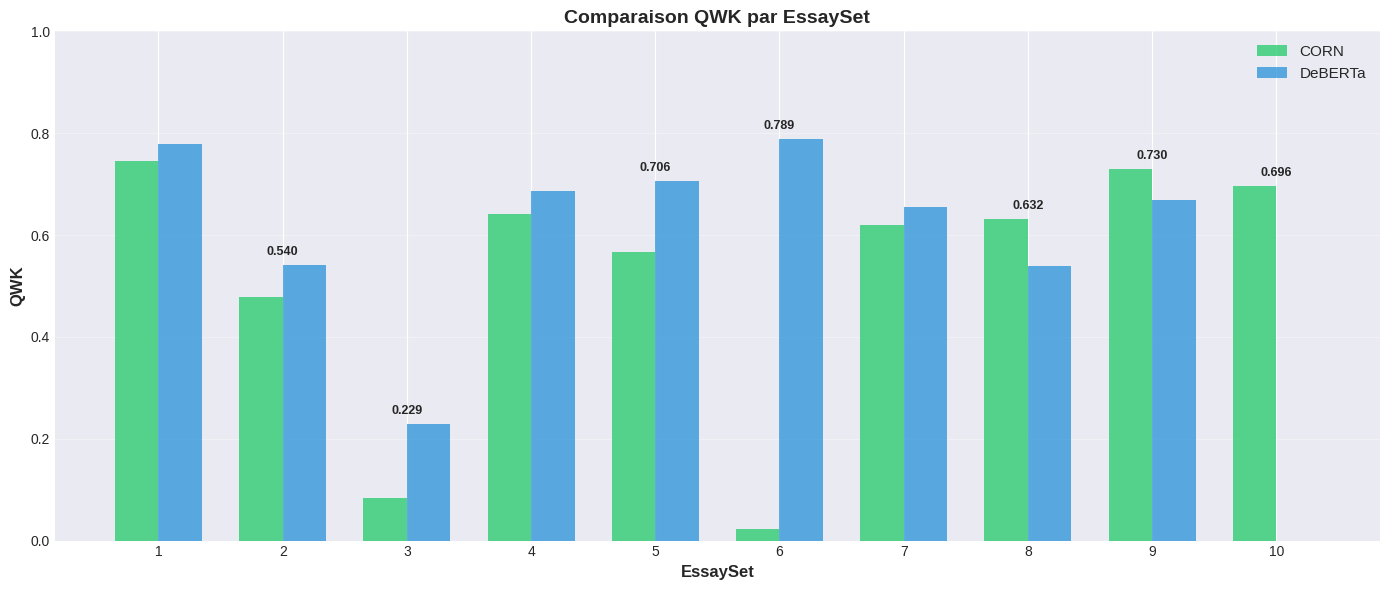

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 1 : Comparaison QWK par EssaySet
# ══════════════════════════════════════════════════════════

df_results = pd.DataFrame(results_by_es)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['corn_qwk'], width, label='CORN', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, df_results['deb_qwk'], width, label='DeBERTa', color='#3498db', alpha=0.8)

ax.set_xlabel('EssaySet', fontsize=12, fontweight='bold')
ax.set_ylabel('QWK', fontsize=12, fontweight='bold')
ax.set_title('Comparaison QWK par EssaySet', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['essay_set'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Annotations
for i, (c, d) in enumerate(zip(df_results['corn_qwk'], df_results['deb_qwk'])):
    if abs(c - d) > 0.05:  # Annoter seulement si différence significative
        winner_val = max(c, d)
        ax.text(i, winner_val + 0.02, f'{winner_val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


📊 Alignement des historiques CORN sur 10 époques (limité par l'arrêt le plus rapide).


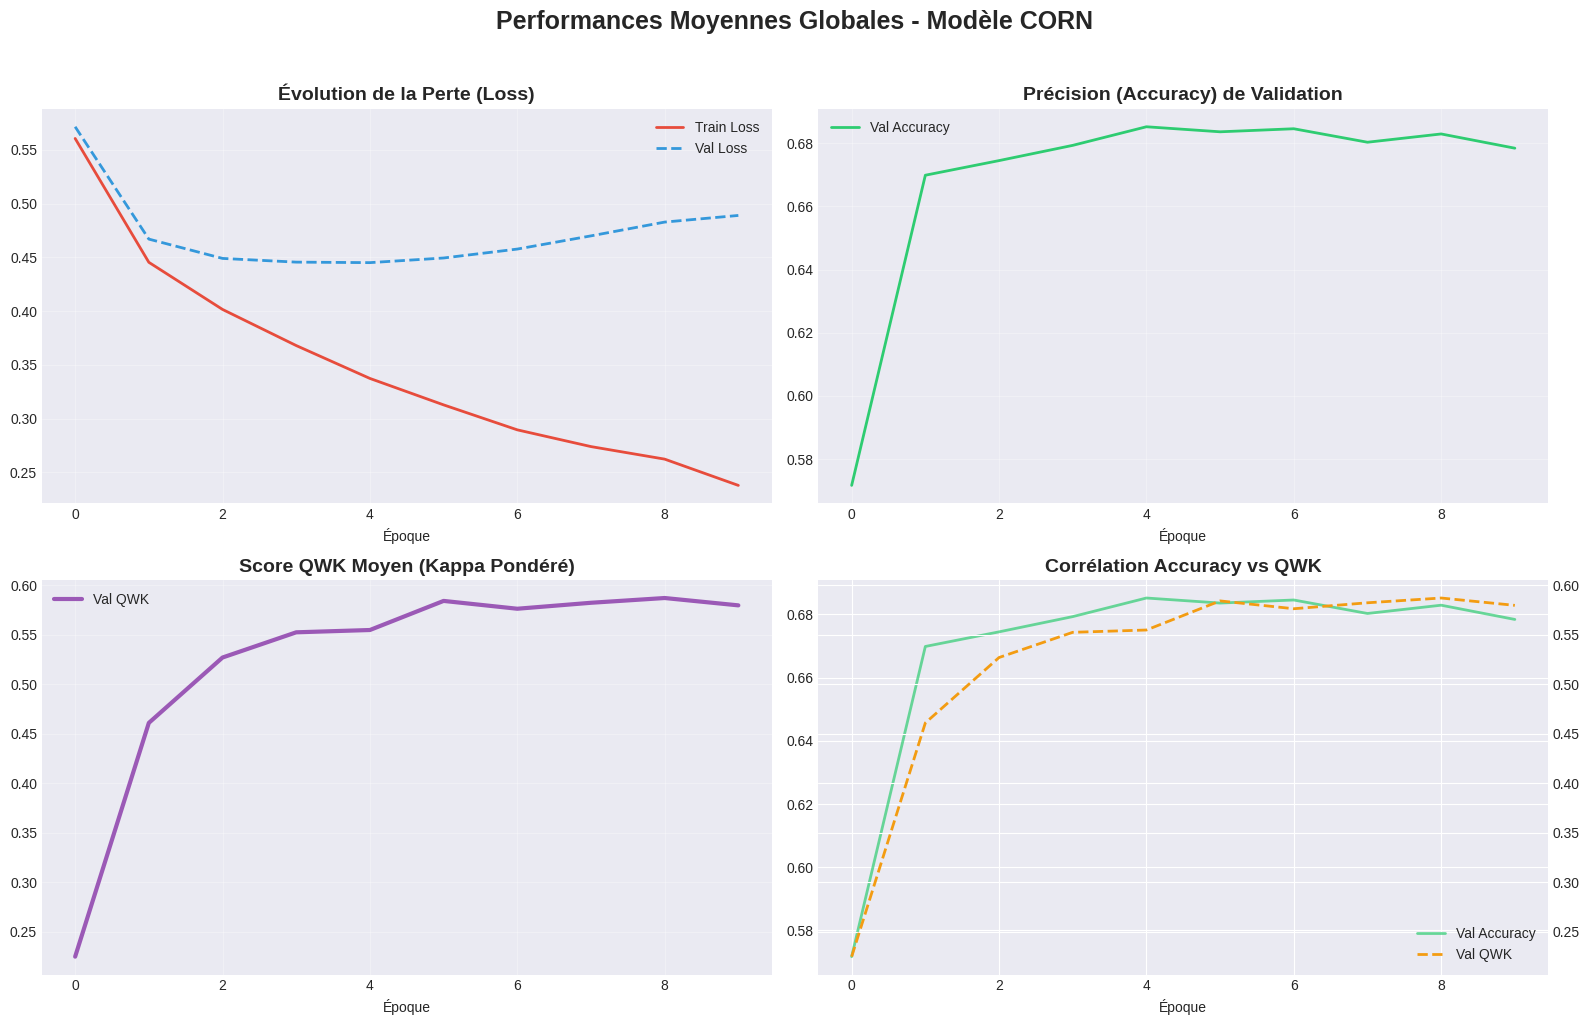

In [ ]:
# ══════════════════════════════════════════════════════════
#nombre des époches augmente
import numpy as np
import matplotlib.pyplot as plt

# --- CHOIX DU DICTIONNAIRE ---
# Utilise corn_models ou deberta_models selon ce que tu veux visualiser
target_models = corn_models
model_name = "CORN" if target_models == corn_models else "DeBERTa"

# 1. Extraire les historiques et trouver la longueur minimale
# On récupère history qui est à l'index 1 du tuple (model, history, ...)
all_histories = [data[1] for data in target_models.values()]

min_epochs = min(len(h['val_loss']) for h in all_histories)

print(f"📊 Alignement des historiques {model_name} sur {min_epochs} époques (limité par l'arrêt le plus rapide).")

# 2. Calculer la moyenne uniquement sur ces époques communes
avg_hist = {}
# Liste des métriques présentes dans tes dictionnaires history
metrics = ['train_loss', 'val_loss', 'val_acc', 'val_qwk']

for key in metrics:
    # On tronque chaque historique à min_epochs pour pouvoir calculer la moyenne
    data_to_average = [h[key][:min_epochs] for h in all_histories]
    avg_hist[key] = np.mean(data_to_average, axis=0)

# ==========================================
# 3. VISUALISATION DES MOYENNES
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Performances Moyennes Globales - Modèle {model_name}", fontsize=18, fontweight='bold', y=1.02)

# Graphique 1: Loss (Train vs Val)
axes[0, 0].plot(avg_hist['train_loss'], linewidth=2, label='Train Loss', color='#e74c3c')
axes[0, 0].plot(avg_hist['val_loss'], linewidth=2, label='Val Loss', color='#3498db', linestyle='--')
axes[0, 0].set_title("Évolution de la Perte (Loss)", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Époque")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2: Accuracy Val
axes[0, 1].plot(avg_hist['val_acc'], linewidth=2, label='Val Accuracy', color='#2ecc71')
axes[0, 1].set_title("Précision (Accuracy) de Validation", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Époque")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3: QWK Moyen (Le plus important pour ce projet)
axes[1, 0].plot(avg_hist['val_qwk'], linewidth=3, label='Val QWK', color='#9b59b6')
axes[1, 0].set_title("Score QWK Moyen (Kappa Pondéré)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Époque")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Graphique 4: Comparaison Acc vs QWK
axes[1, 1].plot(avg_hist['val_acc'], linewidth=2, label='Val Accuracy', color='#2ecc71', alpha=0.7)
ax2 = axes[1, 1].twinx()
ax2.plot(avg_hist['val_qwk'], linewidth=2, label='Val QWK', color='#f39c12', linestyle='--')
axes[1, 1].set_title('Corrélation Accuracy vs QWK', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Époque")
# Fusion des légendes pour les deux axes
lines, labels = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower right')

plt.tight_layout()
plt.show()


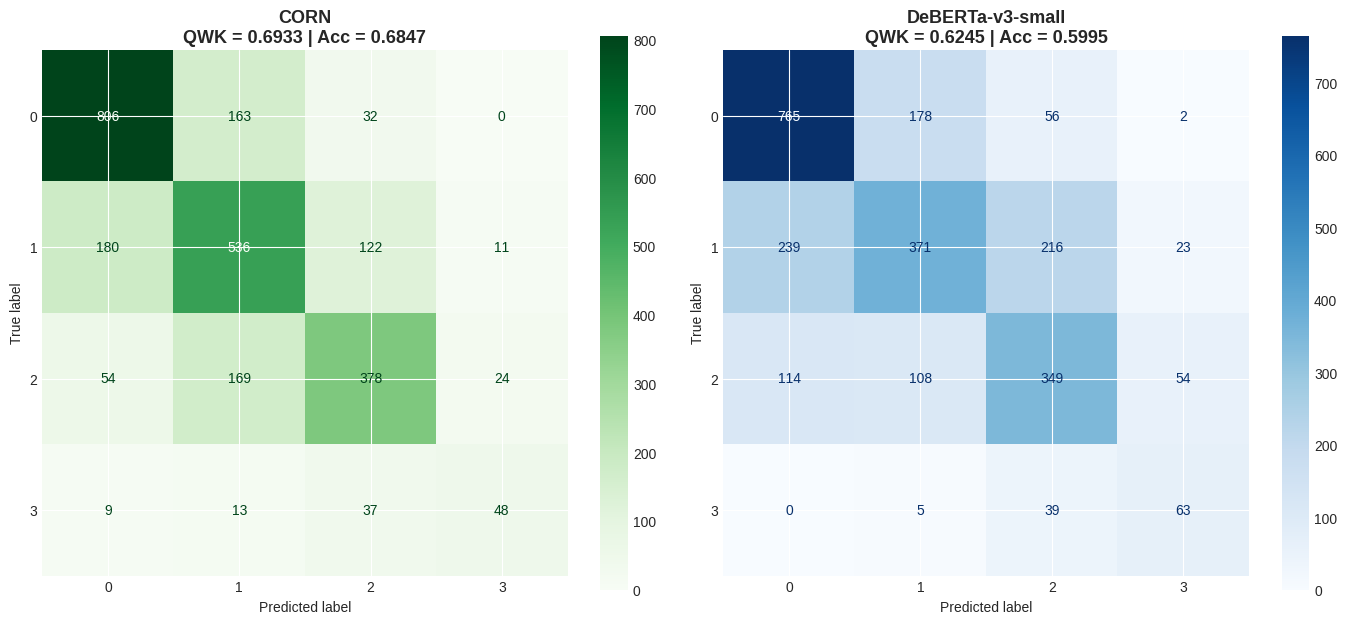


🔍 Analyse des erreurs:

CORN        :  814 erreurs ( 31.5%) | Erreurs extrêmes (Δ≥2): 119
DeBERTa     : 1034 erreurs ( 40.0%) | Erreurs extrêmes (Δ≥2): 200


In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 2 : Matrices de confusion côte à côte
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CORN
cm_corn = confusion_matrix(y_test, preds_corn_test, labels=[0,1,2,3])
disp_corn = ConfusionMatrixDisplay(cm_corn, display_labels=[0,1,2,3])
disp_corn.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title(f'CORN\nQWK = {qwk_corn:.4f} | Acc = {acc_corn:.4f}',
                  fontsize=13, fontweight='bold')

# DeBERTa
cm_deb = confusion_matrix(y_test, preds_deb_test, labels=[0,1,2,3])
disp_deb = ConfusionMatrixDisplay(cm_deb, display_labels=[0,1,2,3])
disp_deb.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'DeBERTa-v3-small\nQWK = {qwk_deb:.4f} | Acc = {acc_deb:.4f}',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyse des erreurs
print('\n🔍 Analyse des erreurs:\n')
for name, preds in [('CORN', preds_corn_test), ('DeBERTa', preds_deb_test)]:
    errors = preds != y_test
    extreme_errors = np.abs(preds - y_test) >= 2
    print(f'{name:12s}: {errors.sum():4d} erreurs ({errors.sum()/len(y_test)*100:5.1f}%) | '
          f'Erreurs extrêmes (Δ≥2): {extreme_errors.sum():3d}')


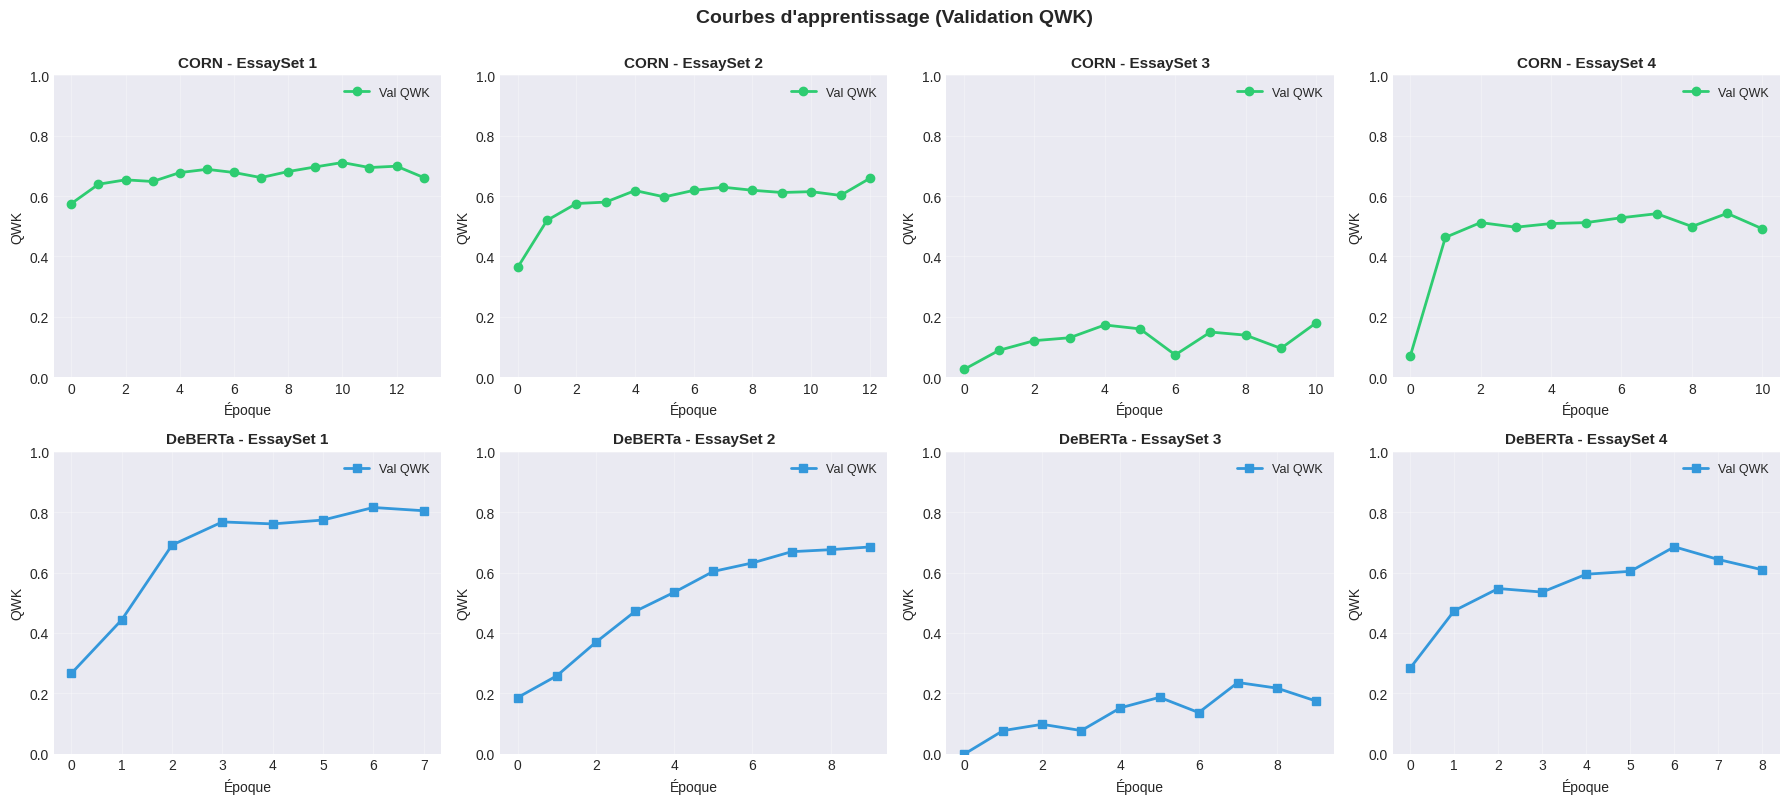

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 3 : Courbes d'entraînement
# ══════════════════════════════════════════════════════════

# Sélectionner 4 questions représentatives
selected_es = sorted(df_test['essay_set'].unique())[:4]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, es in enumerate(selected_es):
    # CORN
    if es in corn_models:
        _, hist_c, _, _ = corn_models[es]
        ax = axes[0, idx]
        ax.plot(hist_c['val_qwk'], marker='o', color='#2ecc71', linewidth=2, label='Val QWK')
        ax.set_title(f'CORN - EssaySet {es}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel('QWK')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.0)

    # DeBERTa
    if es in deberta_models:
        _, _, hist_d, _, _ = deberta_models[es]
        ax = axes[1, idx]
        ax.plot(hist_d['val_qwk'], marker='s', color='#3498db', linewidth=2, label='Val QWK')
        ax.set_title(f'DeBERTa - EssaySet {es}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel('QWK')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.0)

plt.suptitle('Courbes d\'apprentissage (Validation QWK)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


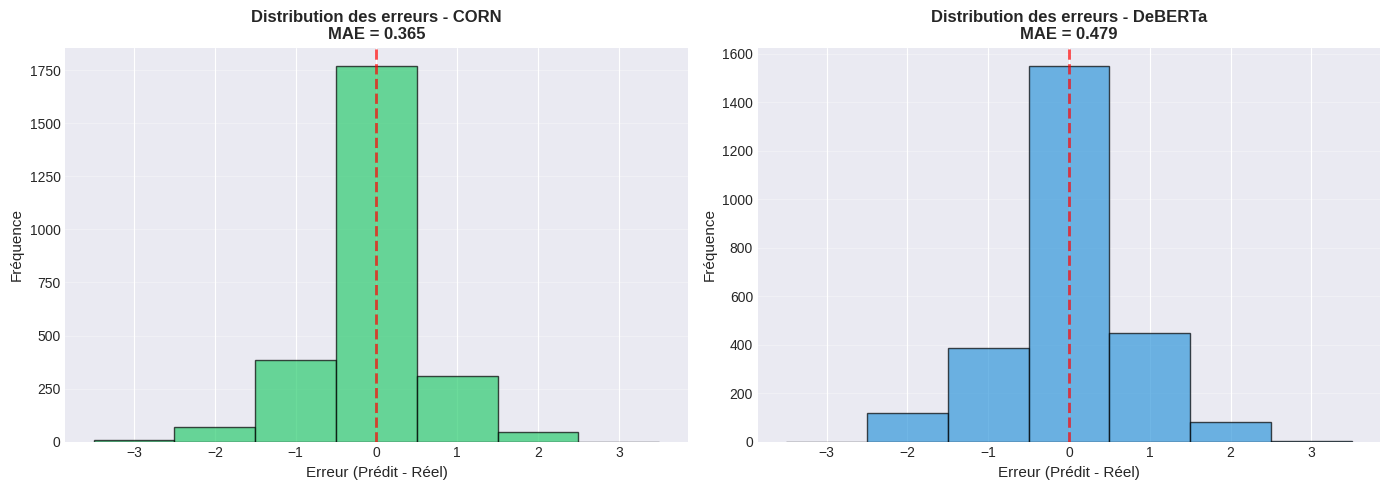

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 4 : Distribution des erreurs
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Erreurs CORN
errors_corn = preds_corn_test - y_test
axes[0].hist(errors_corn, bins=np.arange(-3.5, 4.5, 1), color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Erreur (Prédit - Réel)', fontsize=11)
axes[0].set_ylabel('Fréquence', fontsize=11)
axes[0].set_title(f'Distribution des erreurs - CORN\nMAE = {np.abs(errors_corn).mean():.3f}',
                  fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].grid(axis='y', alpha=0.3)

# Erreurs DeBERTa
errors_deb = preds_deb_test - y_test
axes[1].hist(errors_deb, bins=np.arange(-3.5, 4.5, 1), color='#3498db', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Erreur (Prédit - Réel)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title(f'Distribution des erreurs - DeBERTa\nMAE = {np.abs(errors_deb).mean():.3f}',
                  fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


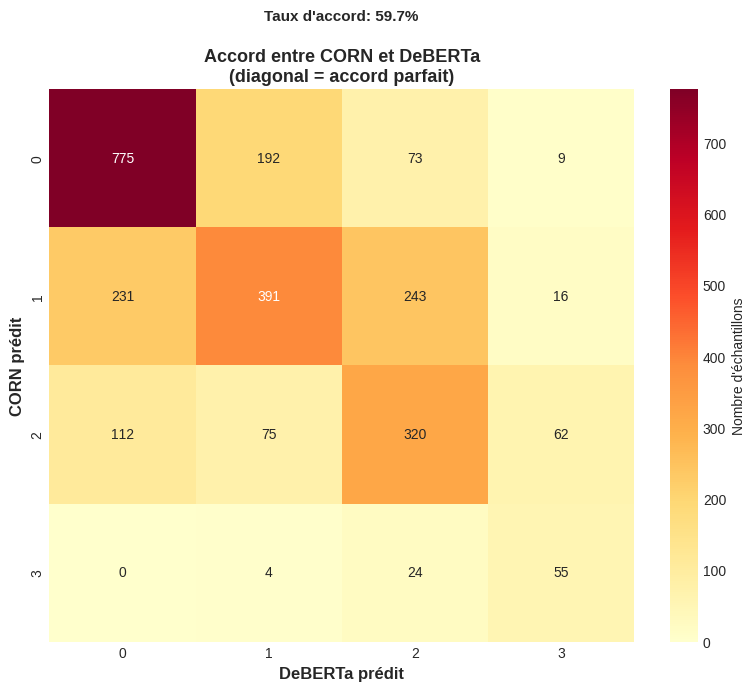

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 5 : Heatmap de comparaison
# ══════════════════════════════════════════════════════════

# Matrice : combien de fois CORN et DeBERTa prédisent la même chose
agreement_matrix = confusion_matrix(preds_corn_test, preds_deb_test, labels=[0,1,2,3])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(agreement_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3],
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_xlabel('DeBERTa prédit', fontsize=12, fontweight='bold')
ax.set_ylabel('CORN prédit', fontsize=12, fontweight='bold')
ax.set_title('Accord entre CORN et DeBERTa\n(diagonal = accord parfait)',
             fontsize=13, fontweight='bold')

# Taux d'accord
agreement_rate = (preds_corn_test == preds_deb_test).sum() / len(y_test)
ax.text(2, -0.5, f'Taux d\'accord: {agreement_rate*100:.1f}%',
        fontsize=11, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()


## **12. Rapport de classification détaillé**


In [ ]:
print('='*70)
print('📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ')
print('='*70)

print('\n🔹 CORN:\n')
print(classification_report(y_test, preds_corn_test,
                            target_names=['Score 0', 'Score 1', 'Score 2', 'Score 3']))

print('\n🔹 DeBERTa-v3-small:\n')
print(classification_report(y_test, preds_deb_test,
                            target_names=['Score 0', 'Score 1', 'Score 2', 'Score 3']))


📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ

🔹 CORN:

              precision    recall  f1-score   support

     Score 0       0.77      0.81      0.79      1001
     Score 1       0.61      0.63      0.62       849
     Score 2       0.66      0.60      0.63       625
     Score 3       0.58      0.45      0.51       107

    accuracy                           0.68      2582
   macro avg       0.65      0.62      0.64      2582
weighted avg       0.68      0.68      0.68      2582


🔹 DeBERTa-v3-small:

              precision    recall  f1-score   support

     Score 0       0.68      0.76      0.72      1001
     Score 1       0.56      0.44      0.49       849
     Score 2       0.53      0.56      0.54       625
     Score 3       0.44      0.59      0.51       107

    accuracy                           0.60      2582
   macro avg       0.55      0.59      0.57      2582
weighted avg       0.60      0.60      0.59      2582



## **13. Conclusion**

### Points clés

1. **Entraînement par question** : Permet de respecter l'hétérogénéité des sujets (science vs littérature, rubrics différentes)

2. **CORN (Régression ordinale)** :
   - Exploite la structure ordinale des scores
   - Réduit les erreurs extrêmes (0↔3)
   - Entraînement rapide avec SBERT figé

3. **DeBERTa-v3-small** :
   - Encodeur adapté à la tâche via fine-tuning
   - Capture mieux les nuances linguistiques
   - Plus coûteux en temps et mémoire

### Recommandations

- Si **temps/mémoire limités** → CORN
- Si **performance maximale recherchée** → DeBERTa (ou ensemble des deux)
- Pour **production** → Considérer un ensemble pondéré pour combiner les forces

### Perspectives d'amélioration

- **DeBERTa-v3-base** (184M params) pour gain de performance
- **Similarité avec réponse de référence** comme feature supplémentaire
- **Data augmentation** (paraphrase) pour classes déséquilibrées
- **Cross-validation** pour estimation plus robuste
